# Identifier les variables influencant les comportements des courbes de charge

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from random import randint

# Racine du projet — 2 niveaux au-dessus de ce notebook
# notebooks/03_visualisation/ -> notebooks/ -> FlexiMax/
ROOT = Path().resolve().parent.parent

DATA_RAW       = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
FIGURES        = ROOT / 'reports' / 'figures'

print('Racine projet :', ROOT)
df_metadata = pd.read_parquet(DATA_PROCESSED / 'metadata_features.parquet')

Racine projet : C:\Users\eassoumou1\FlexiMax


In [3]:
df_metadata["in.ashrae_iecc_climate_zone_2004"].nunique()

17

            PROCEDE : 
            -   On prend 3 bâtiments répondant aux critères par zone ASHRAE (17 zones)
            -   On modélise graphiquement leur courbe de charge quotidienne par minute sur le même graphique
            -   On étudie les différences entre bâtiments au sein d'une même zone ASHRAE
                    -   Différence ponctuelle
                    -   EQM
                    -   Valeurs remarquables (min, max, x=0)
                    -   Intersections 
            -   Etude des corrélations entre variables de df_metadata numérique :
                    -   Calcul des coefficients de Pearson
                    -   Visualisations des corrélations
                    -   Matrice des pvaleurs et visualisation
            -   On étudie les différences entre bâtiments moyens de chaque zone ASHRAE pour comprendre l'influence du climat sur les motifs de consommation 
                    -   Tracé des fonctions sur le même graphique 
                    -   Différence ponctuelle, EQM, valeurs remarquables
                    -   Regression linéaire multiple en fonction des variables explicatives trouvées à l'étape précédente


### I. Différences et similitudes entre 3 bâtiments de la même zone ASHRAE

Filtrage de la dataframe pour ne garder que les bâtiments répondant à nos critères

In [4]:
df_metadataF = df_metadata[df_metadata['in.misc_pool']!='Has Pool']
df_metadataF = df_metadataF[df_metadataF['in.electric_vehicle_ownership']==0]
df_metadataF = df_metadataF[df_metadataF['in.has_pv']==0]
df_metadataF = df_metadataF[df_metadataF['out.electricity.heating.energy_consumption..kwh']!=0]
df_metadataF = df_metadataF[df_metadataF['out.electricity.total.energy_consumption..kwh']!=0]
df_metadataF = df_metadataF[df_metadataF['out.fuel_oil.total.energy_consumption..kwh']==0]
df_metadataF = df_metadataF[df_metadataF['out.natural_gas.total.energy_consumption..kwh']==0]
df_metadataF = df_metadataF[df_metadataF['out.propane.total.energy_consumption..kwh']==0]
df_metadataF

,bldg_id,completed_status,upgrade,in.upgrade_name,weight,applicability,in.sqft..ft2,in.representative_income,in.county_name,in.ahs_region,...,out.propane.hot_water.energy_consumption_intensity..kwh_per_ft2,out.propane.range_oven.energy_consumption_intensity..kwh_per_ft2,out.propane.total.energy_consumption_intensity..kwh_per_ft2,out.site_energy.net.energy_consumption_intensity..kwh_per_ft2,out.site_energy.total.energy_consumption_intensity..kwh_per_ft2,in.slab_perimeter_r,in.slab_under_r,in.duct_leakage,in.duct_insulation,in.duct_location_int
3,4,Success,0,Baseline,253.903673,True,854.0,43219.0,Lubbock County,Non-CBSA West South Central,...,0.0,0.0,0.0,11.668278,11.668278,0.0,0.0,0.0,0,1
7,8,Success,0,Baseline,253.903673,True,854.0,41362.0,Knox County,Non-CBSA East South Central,...,0.0,0.0,0.0,8.757471,8.757471,0.0,0.0,0.0,0,1
13,14,Success,0,Baseline,253.903673,True,1698.0,5484.0,Canyon County,Non-CBSA Mountain,...,0.0,0.0,0.0,12.588248,12.588248,0.0,0.0,0.2,0,3
14,15,Success,0,Baseline,253.903673,True,881.0,940.0,Duval County,Non-CBSA South Atlantic,...,0.0,0.0,0.0,21.882529,21.882529,0.0,0.0,0.2,0,4
17,18,Success,0,Baseline,253.903673,True,881.0,NaN,Cass County,Non-CBSA West South Central,...,0.0,0.0,0.0,7.701349,7.701349,0.0,0.0,0.3,8,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549938,549968,Success,0,Baseline,253.903673,True,1698.0,55156.0,Price County,Non-CBSA East North Central,...,0.0,0.0,0.0,34.424287,34.424287,0.0,0.0,0.2,0,4
549941,549971,Success,0,Baseline,253.903673,True,1138.0,53538.0,Harris County,"CBSA Houston-The Woodlands-Sugar Land, TX",...,0.0,0.0,0.0,10.416900,10.416900,0.0,0.0,0.0,0,1
549947,549977,Success,0,Baseline,253.903673,True,854.0,16241.0,Camden County,"CBSA Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",...,0.0,0.0,0.0,13.690949,13.690949,0.0,0.0,NaN,0,0
549966,549996,Success,0,Baseline,253.903673,True,872.0,15234.0,Story County,Non-CBSA West North Central,...,0.0,0.0,0.0,23.041369,23.041369,0.0,0.0,0.2,0,4


Téléchargement de 3 bâtiments répondant aux critères par zone

In [5]:
ASHRAE_zones = df_metadata["in.ashrae_iecc_climate_zone_2004"].sort_values().unique()
ASHRAE_zones

<ArrowStringArray>
[ '1A',  '2A',  '2B',  '3A',  '3B',  '3C',  '4A',  '4B',  '4C',  '5A',  '5B',
  '6A',  '6B',  '7A', '7AK',  '7B', '8AK']
Length: 17, dtype: str

In [6]:
df_single_zone = df_metadata[df_metadata["in.ashrae_iecc_climate_zone_2004"]=="3A"].reset_index(drop=True)
df_single_zone

,bldg_id,completed_status,upgrade,in.upgrade_name,weight,applicability,in.sqft..ft2,in.representative_income,in.county_name,in.ahs_region,...,out.propane.hot_water.energy_consumption_intensity..kwh_per_ft2,out.propane.range_oven.energy_consumption_intensity..kwh_per_ft2,out.propane.total.energy_consumption_intensity..kwh_per_ft2,out.site_energy.net.energy_consumption_intensity..kwh_per_ft2,out.site_energy.total.energy_consumption_intensity..kwh_per_ft2,in.slab_perimeter_r,in.slab_under_r,in.duct_leakage,in.duct_insulation,in.duct_location_int
0,1,Success,0,Baseline,253.903673,True,1228.0,53672.0,Franklin County,Non-CBSA East South Central,...,0.0,0.0,2.331442,13.537354,13.537354,0.0,0.0,0.0,0,1
1,18,Success,0,Baseline,253.903673,True,881.0,NaN,Cass County,Non-CBSA West South Central,...,0.0,0.0,0.000000,7.701349,7.701349,0.0,0.0,0.3,8,6
2,33,Success,0,Baseline,253.903673,True,634.0,12022.0,Mecklenburg County,Non-CBSA South Atlantic,...,0.0,0.0,0.000000,17.041112,17.041112,0.0,0.0,NaN,0,0
3,43,Success,0,Baseline,253.903673,True,1228.0,64828.0,Clayton County,"CBSA Atlanta-Sandy Springs-Roswell, GA",...,0.0,0.0,0.000000,18.336989,18.336989,0.0,0.0,0.2,4,6
4,44,Success,0,Baseline,253.903673,True,1228.0,75632.0,Comanche County,Non-CBSA West South Central,...,0.0,0.0,0.000000,12.620194,12.620194,0.0,0.0,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73172,549934,Success,0,Baseline,253.903673,True,1698.0,359796.0,Jefferson County,Non-CBSA East South Central,...,0.0,0.0,0.000000,15.040690,15.040690,0.0,0.0,0.3,4,6
73173,549937,Success,0,Baseline,253.903673,True,634.0,61268.0,Comanche County,Non-CBSA West South Central,...,0.0,0.0,0.000000,29.314965,29.314965,0.0,0.0,0.3,4,6
73174,549949,Success,0,Baseline,253.903673,True,854.0,68076.0,Shelby County,Non-CBSA East South Central,...,0.0,0.0,0.000000,6.690188,6.690188,0.0,0.0,0.0,0,1
73175,549963,Success,0,Baseline,253.903673,True,1228.0,22569.0,Putnam County,Non-CBSA South Atlantic,...,0.0,0.0,0.000000,17.137975,17.137975,0.0,0.0,0.2,4,6


In [7]:
# Télecharger les séries temporelles par bâtiment depuis le data lake public OEDI (ResStock 2025, AMY2018)

ROOT           = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / 'data' / 'processed'
DATA_RAW       = ROOT / 'data' / 'raw'

OEDI_BASE = (
    'https://oedi-data-lake.s3.amazonaws.com/'
    'nrel-pds-building-stock/end-use-load-profiles-for-us-building-stock/'
    '2025/resstock_amy2018_release_1/'
    'timeseries_individual_buildings/by_state/upgrade=0'
)

def download_timeseries(bldg_id: int, state: str, save: bool = True) -> pd.DataFrame:
    out = DATA_RAW / f'{bldg_id}-0.parquet'
    if out.exists():    #si le fichier existe déjà on charge localement sans retélécharger
        print(f'Fichier existant trouvé, chargement local : {out}')
        df = pd.read_parquet(out)
    else:
        url = f'{OEDI_BASE}/state={state}/{bldg_id}-0.parquet'
        print(f'Téléchargement : {url}')
        df = pd.read_parquet(url)
        if save:
            #out.parent.mkdir(parents=True, exist_ok=True) 
            df.to_parquet(out)
            print(f'Sauvegardé : {out}')
    print(f'Shape : {df.shape} | {df["timestamp"].iloc[0]} → {df["timestamp"].iloc[-1]}')
    return df

In [8]:
df_zone = df_metadata[df_metadata["in.ashrae_iecc_climate_zone_2004"]=="3A"].reset_index(drop=True)

random_index = randint(0,df_zone.shape[0])
chosen_building = (df_zone["bldg_id"].loc[random_index], df_zone["in.state"].loc[random_index], True)
print(chosen_building)

(np.int64(260784), 'AL', True)


            Attention : cette prochaine cellule télécharge 51 fichiers
            Enlever les guillemets pour l'executer (2min23sec)

In [9]:
#A ne pas executer (les valeurs aléatoires générées par ce code sont téléchargeables dans les cellules en dessous)
"""dataframes = []
acc_zones = 0
acc_df = 0
for e in ASHRAE_zones :
    df_zone = df_metadata[df_metadata["in.ashrae_iecc_climate_zone_2004"]==e].reset_index(drop=True)
    acc_zones +=1
    for i in range(3):
        random_index = randint(0,df_zone.shape[0])
        df_dwnld = download_timeseries(df_zone["bldg_id"].loc[random_index], df_zone["in.state"].loc[random_index], True)
        dataframes.append(df_dwnld)
        acc_df += 1
"""

'dataframes = []\nacc_zones = 0\nacc_df = 0\nfor e in ASHRAE_zones :\n    df_zone = df_metadata[df_metadata["in.ashrae_iecc_climate_zone_2004"]==e].reset_index(drop=True)\n    acc_zones +=1\n    for i in range(3):\n        random_index = randint(0,df_zone.shape[0])\n        df_dwnld = download_timeseries(df_zone["bldg_id"].loc[random_index], df_zone["in.state"].loc[random_index], True)\n        dataframes.append(df_dwnld)\n        acc_df += 1\n'

In [10]:
"""print("Nombre de dataframes téléchargés : "+str(acc_df))
print("Nombre de zones différentes téléchargées : "+str(acc_zones))"""

'print("Nombre de dataframes téléchargés : "+str(acc_df))\nprint("Nombre de zones différentes téléchargées : "+str(acc_zones))'

In [11]:
"""data = []
for i in range(len(dataframes)):
    data.append(int(dataframes[i]["bldg_id"][0]))
data1=[]
for e in data :
    data1.append(df_metadata["in.state"].loc[df_metadata["bldg_id"]==e].iloc[0])
print(data)
print(data1)"""

'data = []\nfor i in range(len(dataframes)):\n    data.append(int(dataframes[i]["bldg_id"][0]))\ndata1=[]\nfor e in data :\n    data1.append(df_metadata["in.state"].loc[df_metadata["bldg_id"]==e].iloc[0])\nprint(data)\nprint(data1)'

In [12]:
dataframes_ids = [515777, 32720, 47526, 187111, 547571, 439033, 535975, 103278, 416708, 219021, 305448, 358653, 445781, 536952, 140479, 282481, 211039, 549429, 189821, 332813, 67620, 360466, 371530, 137306, 179622, 264540, 221745, 518700, 453671, 460575, 315734, 10485, 330117, 235930, 463533, 5887, 165350, 198999, 39270, 269793, 288767, 35334, 288276, 131442, 255720, 238101, 406739, 87816, 352239, 490118, 473623]
dataframes_states = ['HI', 'FL', 'FL', 'FL', 'LA', 'FL', 'AZ', 'AZ', 'AZ', 'SC', 'AR', 'AR', 'CA', 'CA', 'CA', 'CA', 'CA', 'CA', 'VA', 'OH', 'DC', 'NM', 'NM', 'TX', 'WA', 'OR', 'WA', 'OH', 'MI', 'IN', 'WA', 'ID', 'ID', 'WI', 'WI', 'MI', 'ID', 'WY', 'WY', 'MN', 'MN', 'MI', 'AK', 'AK', 'AK', 'CO', 'CO', 'CO', 'AK', 'AK', 'AK']

In [13]:
out = DATA_RAW / f'{189821}-0.parquet'
out.exists()

True

In [14]:
dataframes = []
for i in range(len(dataframes_ids)):
    df_dwnld = download_timeseries(dataframes_ids[i], dataframes_states[i])
    dataframes.append(df_dwnld)

dataframes[0].head(10)

Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\515777-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\32720-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\47526-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\187111-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\547571-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\439033-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant t

,bldg_id,timestamp,in.sqft,out.electricity.ceiling_fan.energy_consumption..kwh,out.electricity.clothes_dryer.energy_consumption..kwh,out.electricity.clothes_washer.energy_consumption..kwh,out.electricity.cooling.energy_consumption..kwh,out.electricity.cooling_fans_pumps.energy_consumption..kwh,out.electricity.dishwasher.energy_consumption..kwh,out.electricity.ev_charging.energy_consumption..kwh,...,out.schedules.lighting_interior,out.schedules.no_space_cooling,out.schedules.no_space_heating,out.schedules.occupants,out.schedules.peak_period,out.schedules.plug_loads_other,out.schedules.plug_loads_tv,out.schedules.power_outage,out.schedules.pre_peak_period,out.schedules.vacancy
0,515777,2018-01-01 00:15:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.751,0.0,0.0,0.75,NaN,0.870,0.572,0.0,NaN,0.0
1,515777,2018-01-01 00:30:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.751,0.0,0.0,0.75,NaN,0.870,0.572,0.0,NaN,0.0
2,515777,2018-01-01 00:45:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.891,0.0,0.0,0.90,NaN,0.932,0.684,0.0,NaN,0.0
3,515777,2018-01-01 01:00:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.971,0.0,0.0,1.00,NaN,0.950,0.864,0.0,NaN,0.0
4,515777,2018-01-01 01:15:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.962,0.0,0.0,1.00,NaN,0.934,0.936,0.0,NaN,0.0
5,515777,2018-01-01 01:30:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.962,0.0,0.0,1.00,NaN,0.934,0.936,0.0,NaN,0.0
6,515777,2018-01-01 01:45:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.962,0.0,0.0,1.00,NaN,0.934,0.936,0.0,NaN,0.0
7,515777,2018-01-01 02:00:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.850,0.0,0.0,1.00,NaN,0.888,0.906,0.0,NaN,0.0
8,515777,2018-01-01 02:15:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.776,0.0,0.0,1.00,NaN,0.857,0.887,0.0,NaN,0.0
9,515777,2018-01-01 02:30:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.667,0.0,0.0,1.00,NaN,0.812,0.756,0.0,NaN,0.0


Visualisation des courbes de charge par zone ASHRAE

            Chaque groupe de 3 bâtiments dans dataframes appartient à une même zone, dans l'ordre de ASHRAE_zones

In [44]:
ASHRAE_zones

<ArrowStringArray>
[ '1A',  '2A',  '2B',  '3A',  '3B',  '3C',  '4A',  '4B',  '4C',  '5A',  '5B',
  '6A',  '6B',  '7A', '7AK',  '7B', '8AK']
Length: 17, dtype: str

In [ ]:
for i in range(3):
    if df_metadata[df_metadata["in.ashrae_iecc_climate_zone_2004"]=="1A"].loc[df_metadata["bldg_id"]==dataframes[i]["bldg_id"].iloc[0]].size != 0:
        print("Correct zone 1A")
    else:
        print("Wrong zones")

Correct zone 1A
Correct zone 1A
Correct zone 1A


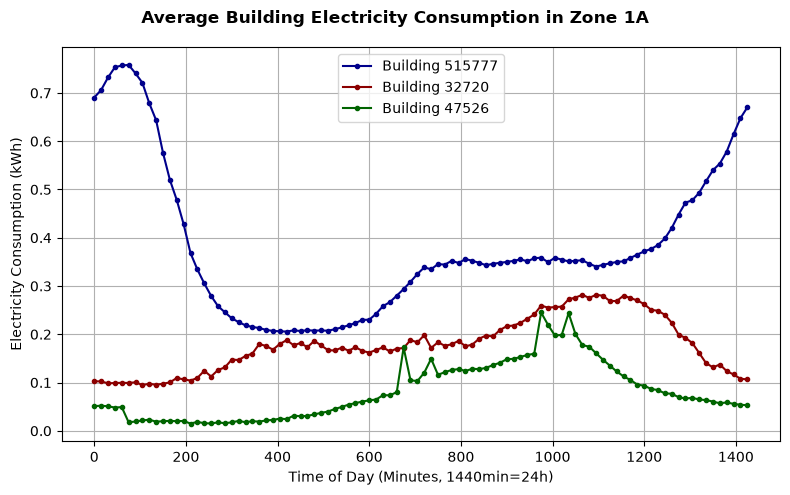

In [ ]:
#Ajout des colonnes 'minute'
dataframes[0]["minute"] = dataframes[0]["timestamp"].dt.minute + dataframes[0]["timestamp"].dt.hour*60
dataframes[1]["minute"] = dataframes[1]["timestamp"].dt.minute + dataframes[1]["timestamp"].dt.hour*60
dataframes[2]["minute"] = dataframes[2]["timestamp"].dt.minute + dataframes[2]["timestamp"].dt.hour*60

#Groupement
df0 = dataframes[0].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df1 = dataframes[1].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df2 = dataframes[2].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()

#Tracage des courbes
plt.figure(figsize=(8,5))

plt.plot(df0.index, df0.values, marker=".", color='darkblue', label="Building "+str(dataframes[0]["bldg_id"].loc[3]))
plt.plot(df1.index, df1.values, marker=".", color='darkred', label="Building "+str(dataframes[1]["bldg_id"].loc[3]))
plt.plot(df2.index, df2.values, marker=".", color='darkgreen', label="Building "+str(dataframes[2]["bldg_id"].loc[3]))

plt.suptitle('Average Building Electricity Consumption in Zone 1A', fontsize=12, fontweight='bold')
plt.xlabel("Time of Day (Minutes, 1440min=24h)")
plt.ylabel("Electricity Consumption (kWh)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

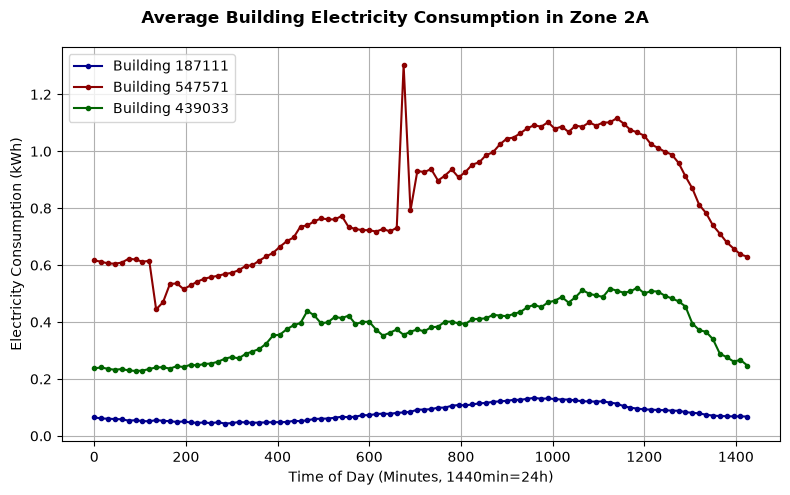

In [64]:
#Ajout des colonnes 'minute'
dataframes[3]["minute"] = dataframes[3]["timestamp"].dt.minute + dataframes[3]["timestamp"].dt.hour*60
dataframes[4]["minute"] = dataframes[4]["timestamp"].dt.minute + dataframes[4]["timestamp"].dt.hour*60
dataframes[5]["minute"] = dataframes[5]["timestamp"].dt.minute + dataframes[5]["timestamp"].dt.hour*60

#Groupement
df3 = dataframes[3].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df4 = dataframes[4].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df5 = dataframes[5].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()

#Tracage des courbes
plt.figure(figsize=(8,5))

plt.plot(df3.index, df3.values, marker=".", color='darkblue', label="Building "+str(dataframes[3]["bldg_id"].loc[3]))
plt.plot(df4.index, df4.values, marker=".", color='darkred', label="Building "+str(dataframes[4]["bldg_id"].loc[3]))
plt.plot(df5.index, df5.values, marker=".", color='darkgreen', label="Building "+str(dataframes[5]["bldg_id"].loc[3]))

plt.suptitle('Average Building Electricity Consumption in Zone 2A', fontsize=12, fontweight='bold')
plt.xlabel("Time of Day (Minutes, 1440min=24h)")
plt.ylabel("Electricity Consumption (kWh)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

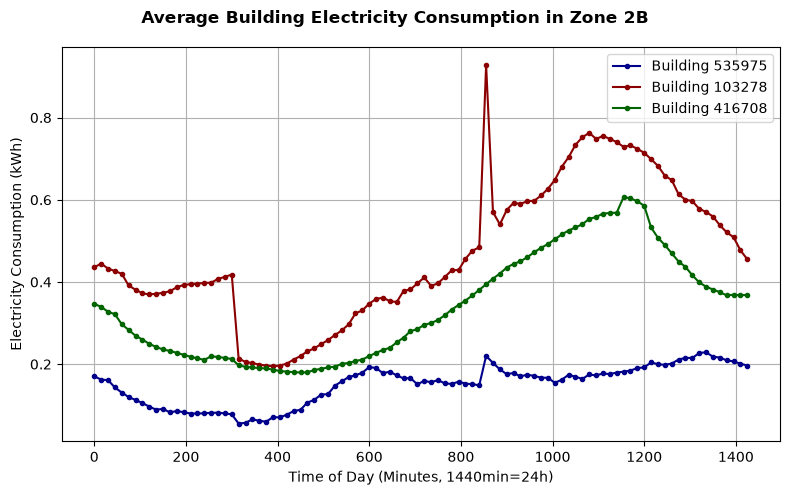

In [67]:
#Ajout des colonnes 'minute'
dataframes[6]["minute"] = dataframes[6]["timestamp"].dt.minute + dataframes[6]["timestamp"].dt.hour*60
dataframes[7]["minute"] = dataframes[7]["timestamp"].dt.minute + dataframes[7]["timestamp"].dt.hour*60
dataframes[8]["minute"] = dataframes[8]["timestamp"].dt.minute + dataframes[8]["timestamp"].dt.hour*60

#Groupement
df6 = dataframes[6].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df7 = dataframes[7].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df8 = dataframes[8].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()

#Tracage des courbes
plt.figure(figsize=(8,5))

plt.plot(df6.index, df6.values, marker=".", color='darkblue', label="Building "+str(dataframes[6]["bldg_id"].loc[3]))
plt.plot(df7.index, df7.values, marker=".", color='darkred', label="Building "+str(dataframes[7]["bldg_id"].loc[3]))
plt.plot(df8.index, df8.values, marker=".", color='darkgreen', label="Building "+str(dataframes[8]["bldg_id"].loc[3]))

plt.suptitle('Average Building Electricity Consumption in Zone 2B', fontsize=12, fontweight='bold')
plt.xlabel("Time of Day (Minutes, 1440min=24h)")
plt.ylabel("Electricity Consumption (kWh)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

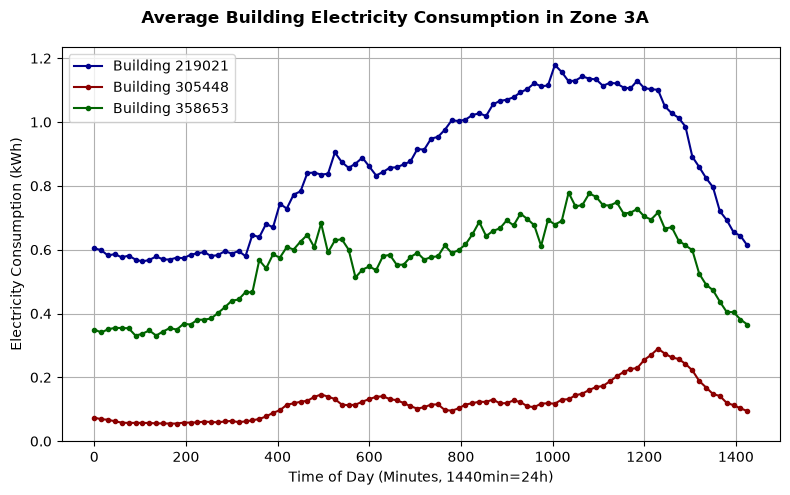

In [68]:
#Ajout des colonnes 'minute'
dataframes[9]["minute"] = dataframes[9]["timestamp"].dt.minute + dataframes[9]["timestamp"].dt.hour*60
dataframes[10]["minute"] = dataframes[10]["timestamp"].dt.minute + dataframes[10]["timestamp"].dt.hour*60
dataframes[11]["minute"] = dataframes[11]["timestamp"].dt.minute + dataframes[11]["timestamp"].dt.hour*60

#Groupement
df9 = dataframes[9].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df10 = dataframes[10].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df11 = dataframes[11].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()

#Tracage des courbes
plt.figure(figsize=(8,5))

plt.plot(df9.index, df9.values, marker=".", color='darkblue', label="Building "+str(dataframes[9]["bldg_id"].loc[3]))
plt.plot(df10.index, df10.values, marker=".", color='darkred', label="Building "+str(dataframes[10]["bldg_id"].loc[3]))
plt.plot(df11.index, df11.values, marker=".", color='darkgreen', label="Building "+str(dataframes[11]["bldg_id"].loc[3]))

plt.suptitle('Average Building Electricity Consumption in Zone 3A', fontsize=12, fontweight='bold')
plt.xlabel("Time of Day (Minutes, 1440min=24h)")
plt.ylabel("Electricity Consumption (kWh)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

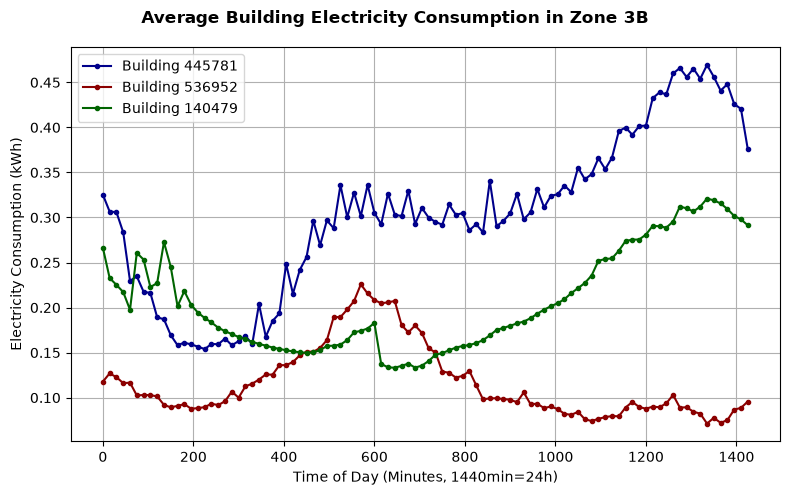

In [69]:
#Ajout des colonnes 'minute'
dataframes[12]["minute"] = dataframes[12]["timestamp"].dt.minute + dataframes[12]["timestamp"].dt.hour*60
dataframes[13]["minute"] = dataframes[13]["timestamp"].dt.minute + dataframes[13]["timestamp"].dt.hour*60
dataframes[14]["minute"] = dataframes[14]["timestamp"].dt.minute + dataframes[14]["timestamp"].dt.hour*60

#Groupement
df12 = dataframes[12].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df13 = dataframes[13].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df14 = dataframes[14].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()

#Tracage des courbes
plt.figure(figsize=(8,5))

plt.plot(df12.index, df12.values, marker=".", color='darkblue', label="Building "+str(dataframes[12]["bldg_id"].loc[3]))
plt.plot(df13.index, df13.values, marker=".", color='darkred', label="Building "+str(dataframes[13]["bldg_id"].loc[3]))
plt.plot(df14.index, df14.values, marker=".", color='darkgreen', label="Building "+str(dataframes[14]["bldg_id"].loc[3]))

plt.suptitle('Average Building Electricity Consumption in Zone 3B', fontsize=12, fontweight='bold')
plt.xlabel("Time of Day (Minutes, 1440min=24h)")
plt.ylabel("Electricity Consumption (kWh)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

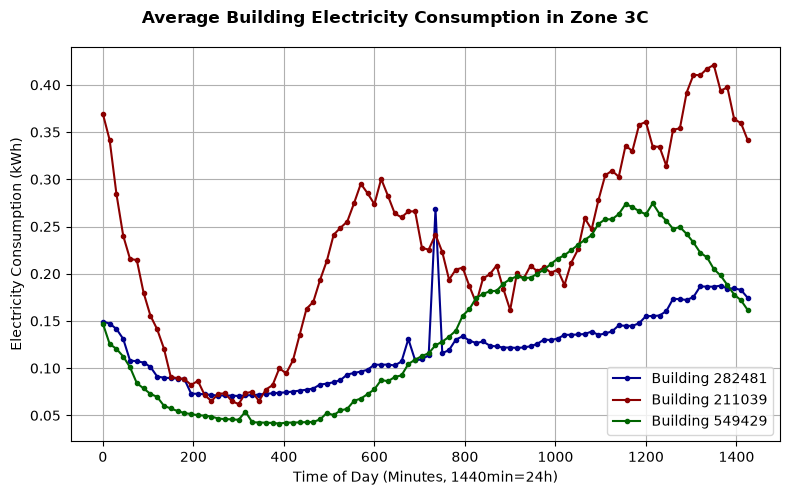

In [71]:
#Ajout des colonnes 'minute'
dataframes[15]["minute"] = dataframes[15]["timestamp"].dt.minute + dataframes[15]["timestamp"].dt.hour*60
dataframes[16]["minute"] = dataframes[16]["timestamp"].dt.minute + dataframes[16]["timestamp"].dt.hour*60
dataframes[17]["minute"] = dataframes[17]["timestamp"].dt.minute + dataframes[17]["timestamp"].dt.hour*60

#Groupement
df15 = dataframes[15].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df16 = dataframes[16].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df17 = dataframes[17].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()

#Tracage des courbes
plt.figure(figsize=(8,5))

plt.plot(df15.index, df15.values, marker=".", color='darkblue', label="Building "+str(dataframes[15]["bldg_id"].loc[3]))
plt.plot(df16.index, df16.values, marker=".", color='darkred', label="Building "+str(dataframes[16]["bldg_id"].loc[3]))
plt.plot(df17.index, df17.values, marker=".", color='darkgreen', label="Building "+str(dataframes[17]["bldg_id"].loc[3]))

plt.suptitle('Average Building Electricity Consumption in Zone 3C', fontsize=12, fontweight='bold')
plt.xlabel("Time of Day (Minutes, 1440min=24h)")
plt.ylabel("Electricity Consumption (kWh)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

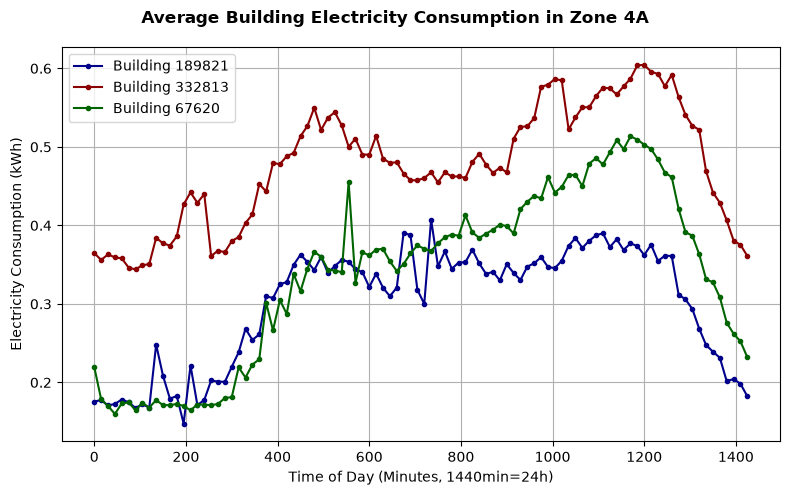

In [72]:
#Ajout des colonnes 'minute'
dataframes[18]["minute"] = dataframes[18]["timestamp"].dt.minute + dataframes[18]["timestamp"].dt.hour*60
dataframes[19]["minute"] = dataframes[19]["timestamp"].dt.minute + dataframes[19]["timestamp"].dt.hour*60
dataframes[20]["minute"] = dataframes[20]["timestamp"].dt.minute + dataframes[20]["timestamp"].dt.hour*60

#Groupement
df18 = dataframes[18].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df19 = dataframes[19].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df20 = dataframes[20].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()

#Tracage des courbes
plt.figure(figsize=(8,5))

plt.plot(df18.index, df18.values, marker=".", color='darkblue', label="Building "+str(dataframes[18]["bldg_id"].loc[3]))
plt.plot(df19.index, df19.values, marker=".", color='darkred', label="Building "+str(dataframes[19]["bldg_id"].loc[3]))
plt.plot(df20.index, df20.values, marker=".", color='darkgreen', label="Building "+str(dataframes[20]["bldg_id"].loc[3]))

plt.suptitle('Average Building Electricity Consumption in Zone 4A', fontsize=12, fontweight='bold')
plt.xlabel("Time of Day (Minutes, 1440min=24h)")
plt.ylabel("Electricity Consumption (kWh)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

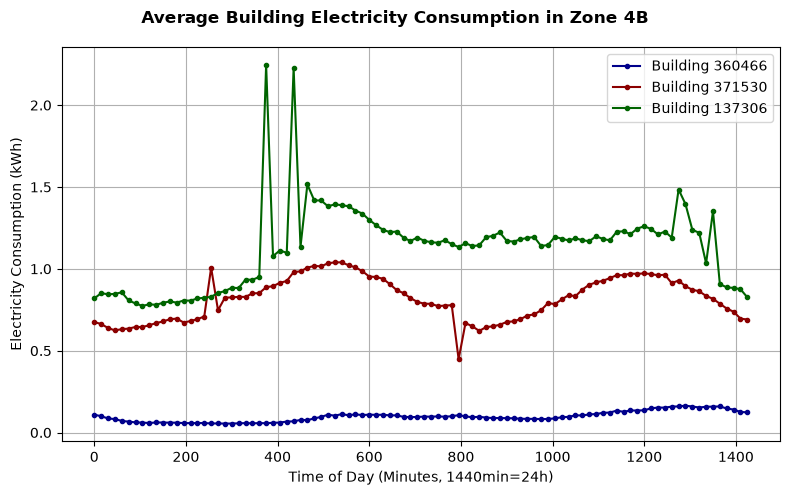

In [73]:
#Ajout des colonnes 'minute'
dataframes[21]["minute"] = dataframes[21]["timestamp"].dt.minute + dataframes[21]["timestamp"].dt.hour*60
dataframes[22]["minute"] = dataframes[22]["timestamp"].dt.minute + dataframes[22]["timestamp"].dt.hour*60
dataframes[23]["minute"] = dataframes[23]["timestamp"].dt.minute + dataframes[23]["timestamp"].dt.hour*60

#Groupement
df21 = dataframes[21].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df22 = dataframes[22].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df23 = dataframes[23].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()

#Tracage des courbes
plt.figure(figsize=(8,5))

plt.plot(df21.index, df21.values, marker=".", color='darkblue', label="Building "+str(dataframes[21]["bldg_id"].loc[3]))
plt.plot(df22.index, df22.values, marker=".", color='darkred', label="Building "+str(dataframes[22]["bldg_id"].loc[3]))
plt.plot(df23.index, df23.values, marker=".", color='darkgreen', label="Building "+str(dataframes[23]["bldg_id"].loc[3]))

plt.suptitle('Average Building Electricity Consumption in Zone 4B', fontsize=12, fontweight='bold')
plt.xlabel("Time of Day (Minutes, 1440min=24h)")
plt.ylabel("Electricity Consumption (kWh)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

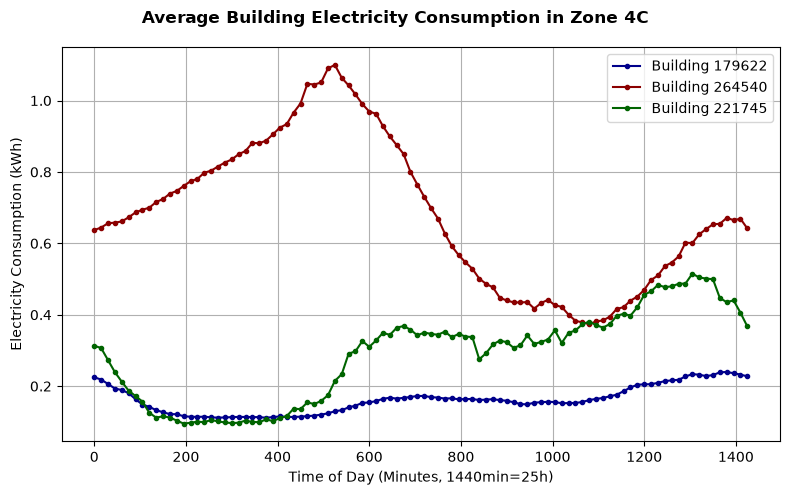

In [77]:
#Ajout des colonnes 'minute'
dataframes[24]["minute"] = dataframes[24]["timestamp"].dt.minute + dataframes[24]["timestamp"].dt.hour*60
dataframes[25]["minute"] = dataframes[25]["timestamp"].dt.minute + dataframes[25]["timestamp"].dt.hour*60
dataframes[26]["minute"] = dataframes[26]["timestamp"].dt.minute + dataframes[26]["timestamp"].dt.hour*60

#Groupement
df24 = dataframes[24].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df25 = dataframes[25].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df26 = dataframes[26].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()

#Tracage des courbes
plt.figure(figsize=(8,5))

plt.plot(df24.index, df24.values, marker=".", color='darkblue', label="Building "+str(dataframes[24]["bldg_id"].loc[3]))
plt.plot(df25.index, df25.values, marker=".", color='darkred', label="Building "+str(dataframes[25]["bldg_id"].loc[3]))
plt.plot(df26.index, df26.values, marker=".", color='darkgreen', label="Building "+str(dataframes[26]["bldg_id"].loc[3]))

plt.suptitle('Average Building Electricity Consumption in Zone 4C', fontsize=12, fontweight='bold')
plt.xlabel("Time of Day (Minutes, 1440min=25h)")
plt.ylabel("Electricity Consumption (kWh)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Analyse des différences entre bâtiments

### II. Corrélations entre variables de df_metadata

### III. Différences et similitudes entre le bâtiment moyen de zones ASHRAE différentes

In [16]:
df_metadata.groupby("in.ashrae_iecc_climate_zone_2004").mean(numeric_only=True)
#par_etat = df_metadata.groupby('in.state', as_index=False).agg(nb=(CONSO_COL, 'count'),conso_moy=(CONSO_COL, 'mean')).sort_values('nb', ascending=False).head(20)

,bldg_id,upgrade,weight,applicability,in.sqft..ft2,in.representative_income,in.aiannh_area,in.bathroom_spot_vent_hour,in.bedrooms,in.clothes_dryer_usage_level,...,out.propane.hot_water.energy_consumption_intensity..kwh_per_ft2,out.propane.range_oven.energy_consumption_intensity..kwh_per_ft2,out.propane.total.energy_consumption_intensity..kwh_per_ft2,out.site_energy.net.energy_consumption_intensity..kwh_per_ft2,out.site_energy.total.energy_consumption_intensity..kwh_per_ft2,in.slab_perimeter_r,in.slab_under_r,in.duct_leakage,in.duct_insulation,in.duct_location_int
in.ashrae_iecc_climate_zone_2004,,,,,,,,,,,,,,,,,,,,,
1A,275131.423744,0.0,253.903673,1.0,1490.732217,86183.773438,0.003856,11.114155,2.483409,1.003044,...,0.033040,0.017369,0.054011,8.480225,8.750102,0.242009,0.602740,0.097378,1.261695,2.179097
2A,275980.366247,0.0,253.903673,1.0,1677.693929,77383.664062,0.005677,10.940153,2.775763,0.999275,...,0.046709,0.014433,0.106366,10.680764,10.701381,0.339460,0.755454,0.124685,2.583379,3.350627
2B,277383.943457,0.0,253.903673,1.0,1812.311907,79009.609375,0.00663,10.973570,2.841054,1.000424,...,0.034119,0.012119,0.058039,10.588064,10.769260,0.381251,0.471038,0.125251,2.912975,3.271572
3A,275285.895514,0.0,253.903673,1.0,1692.800456,72897.531250,0.083073,11.004892,2.828976,1.000599,...,0.074145,0.018047,0.402980,13.387066,13.394278,0.246389,0.491275,0.138856,2.031895,3.298072
3B,274750.884327,0.0,253.903673,1.0,1548.949923,91666.406250,0.003014,11.021780,2.648539,0.999076,...,0.065178,0.016863,0.154090,10.655740,10.882327,0.215358,0.288448,0.139107,1.765484,2.768341
3C,277001.096944,0.0,253.903673,1.0,1515.077943,136269.734375,0.000155,11.031177,2.597410,0.999100,...,0.073037,0.020057,0.176593,10.431785,10.612984,0.113231,0.179153,0.140148,1.106251,2.462463
4A,274800.808565,0.0,253.903673,1.0,1637.773164,89115.062500,0.001588,10.997771,2.688429,1.000225,...,0.077047,0.019511,0.561529,17.018915,17.039168,0.382845,0.275850,0.117033,0.964785,2.326003
4B,275480.514346,0.0,253.903673,1.0,1671.424271,69012.890625,0.009643,10.808796,2.821731,1.006820,...,0.302858,0.037185,1.338502,14.840714,14.979574,0.199906,0.298683,0.134757,1.912512,2.980950
4C,273693.332639,0.0,253.903673,1.0,1583.756439,95503.125000,0.016098,10.809533,2.703283,1.000189,...,0.098522,0.033014,0.330781,13.476229,13.497549,0.666035,0.268308,0.147365,1.120960,2.217740
